<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
# Write your code here
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 114 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    ResponseId                      65437 non-null  int64  
 1    MainBranch                      65437 non-null  str    
 2    Age                             65437 non-null  str    
 3    Employment                      65437 non-null  str    
 4    RemoteWork                      54806 non-null  str    
 5    Check                           65437 non-null  str    
 6    CodingActivities                54466 non-null  str    
 7    EdLevel                         60784 non-null  str    
 8    LearnCode                       60488 non-null  str    
 9    LearnCodeOnline                 49237 non-null  str    
 10   TechDoc                         40897 non-null  str    
 11   YearsCode                       59869 non-null  str    
 12   YearsCodePro               

<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [4]:
# Write your code here
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [5]:
# Write your code here

df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [6]:
df['EdLevel'] = df['EdLevel'].str.replace(r'\s*\(.*?\)', '', regex=True)
df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree                                         24942
Master’s degree                                           15557
Some college/university study without earning a degree     7651
Secondary school                                           5793
Professional degree                                        2970
Associate degree                                           1793
Primary/elementary school                                  1146
Something else                                              932
Name: count, dtype: int64

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [7]:
## Write your code here

Employment_binary=pd.get_dummies(df['Employment'])
Employment_binary

,"Employed, full-time","Employed, full-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Student, full-time;Not employed, but looking for work;Retired","Student, full-time;Not employed, but looking for work;Student, part-time","Student, full-time;Retired","Student, full-time;Student, part-time","Student, full-time;Student, part-time;Employed, part-time","Student, full-time;Student, part-time;Retired","Student, part-time","Student, part-time;Employed, part-time","Student, part-time;Retired"
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65433,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65434,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65435,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [8]:
## Write your code here
empty_df=df.isnull().sum().reset_index(name='number_of_NaN')
empty_df.sort_values('number_of_NaN', ascending=False).head(10)

,index,number_of_NaN
75,AINextMuch less integrated,64289
74,AINextLess integrated,63082
72,AINextNo change,52939
71,AINextMuch more integrated,51999
36,EmbeddedAdmired,48704
35,EmbeddedWantToWorkWith,47837
34,EmbeddedHaveWorkedWith,43223
112,ConvertedCompYearly,42002
70,AIToolNot interested in Using,41023
73,AINextMore integrated,41009


In [9]:
df['ConvertedCompYearly']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
65432   NaN
65433   NaN
65434   NaN
65435   NaN
65436   NaN
Name: ConvertedCompYearly, Length: 65437, dtype: float64

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [10]:
## Write your code here

print('number_of_null_values before imputation:',df['ConvertedCompYearly'].isnull().sum())

median=df['ConvertedCompYearly'].median()
df['ConvertedCompYearly']=df['ConvertedCompYearly'].fillna(median, axis=0)

print('number_of_null_values after imputation:',df['ConvertedCompYearly'].isnull().sum())
df['ConvertedCompYearly']

number_of_null_values before imputation: 42002
number_of_null_values after imputation: 0


0        65000.0
1        65000.0
2        65000.0
3        65000.0
4        65000.0
          ...   
65432    65000.0
65433    65000.0
65434    65000.0
65435    65000.0
65436    65000.0
Name: ConvertedCompYearly, Length: 65437, dtype: float64

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [11]:
## Write your code here
print('number_of_null_values before imputation:',df['RemoteWork'].isnull().sum())
print(df['RemoteWork'].value_counts())

most_frequent=df['RemoteWork'].mode()[0]
df['RemoteWork']=df['RemoteWork'].fillna(most_frequent, axis=0)

print('number_of_null_values after imputation:',df['RemoteWork'].isnull().sum())

number_of_null_values before imputation: 10631
RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64
number_of_null_values after imputation: 0


In [21]:
print('most_frequent_value_in_RemoteWork',most_frequent)

most_frequent_value_in_RemoteWork Hybrid (some remote, some in-person)


### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [12]:
## Write your code here

comp=df['ConvertedCompYearly']
comp_min=comp.min()
comp_max=comp.max()

df['normalaized_comp']=(comp-comp_min)/(comp_max-comp_min)
df['normalaized_comp']

0        0.003998
1        0.003998
2        0.003998
3        0.003998
4        0.003998
           ...   
65432    0.003998
65433    0.003998
65434    0.003998
65435    0.003998
65436    0.003998
Name: normalaized_comp, Length: 65437, dtype: float64

In [13]:
print(len(df['normalaized_comp'].unique()))

6113


<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [14]:
## Write your code here

df['log_comp']=np.log(df['ConvertedCompYearly']+1)  # Adding 1 to avoid log(0)
df['log_comp']

0        11.082158
1        11.082158
2        11.082158
3        11.082158
4        11.082158
           ...    
65432    11.082158
65433    11.082158
65434    11.082158
65435    11.082158
65436    11.082158
Name: log_comp, Length: 65437, dtype: float64

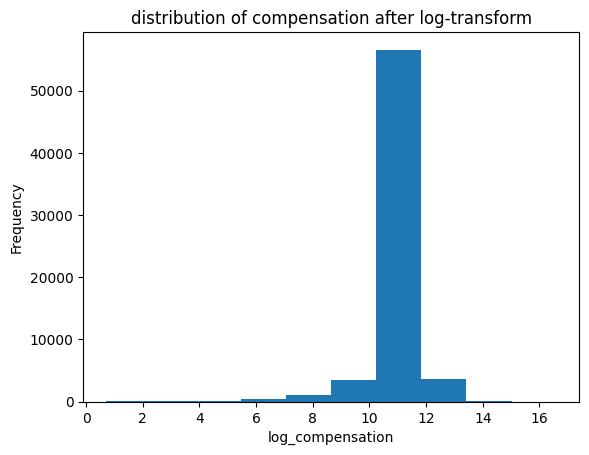

In [15]:
df['log_comp'].plot(kind='hist')
plt.xlabel('log_compensation')
plt.title('distribution of compensation after log-transform')
plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [16]:
df['YearsCodePro'].value_counts()

YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
27                     380
21                     380
28                     342
35                     285
29                     196
32                     194
40                     194
34                     169
38                     134
33             

In [17]:
df['YearsCodePro']=df['YearsCodePro'].replace('Less than 1 year', 0)
df['YearsCodePro']=df['YearsCodePro'].replace('More than 50 years', 55)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
years_median=df['YearsCodePro'].median()
print('years_median:',years_median)

years_median: 7.0


In [18]:
print('number_of_null_values before imputation:',df['YearsCodePro'].isnull().sum())
df['YearsCodePro']=df['YearsCodePro'].fillna(years_median)
df['YearsCodePro']=df['YearsCodePro'].astype('int')

number_of_null_values before imputation: 13827


In [19]:
print(df['YearsCodePro'].unique())
print(len(df['YearsCodePro']))
print('number_of_null_values after imputation:',df['YearsCodePro'].isnull().sum())

[ 7 17 27 11 25 12 10  3  0 18 37 15 20  6  2 16  8 14  4 45  1 24 29  5
 30 26  9 33 13 35 23 22 31 19 21 28 34 32 40 50 39 44 42 41 36 38 55 43
 47 48 46 49]
65437
number_of_null_values after imputation: 0


In [20]:
## Write your code here
exp_range=[0,2,5,10,15,20, df['YearsCodePro'].max()]
exp_names=['junior','mid','senior','expert','master','veteran']
df['ExperienceLevel']=pd.cut(df['YearsCodePro'], bins=exp_range, right=True, labels=exp_names, include_lowest=True)
df[['YearsCodePro','ExperienceLevel']]

,YearsCodePro,ExperienceLevel
0,7,senior
1,17,master
2,27,veteran
3,7,senior
4,7,senior
...,...,...
65432,3,mid
65433,7,senior
65434,5,mid
65435,2,junior


### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
